# MTCG: Plotting Results for the Sioux Falls Case Study

## 1. Import Libraries

This notebook visualises results from the **Multi-Template Computational Graph (MTCG)** model for the Sioux Falls network case study.

In [643]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from sklearn.metrics import r2_score

# ========== CONFIG: Set the estimation folder here ==========
estimation_dir = "Estimations (S=4 k=5)"
# =============================================================

# Derive figure output directory from estimation_dir
figure_dir = estimation_dir.replace("Estimations", "Figures")
os.makedirs(figure_dir, exist_ok=True)

print(f"Reading results from: {estimation_dir}")
print(f"Saving figures and tables to: {figure_dir}")

Reading results from: Estimations (S=4 k=5)
Saving figures and tables to: Figures (S=4 k=5)


## 2. Load Link Flow Estimation Results

In [644]:
link_flow = pd.read_excel(f'{estimation_dir}/link_flow_estimation.xlsx')
link_flow

,Estimation,Observation
0,3413.034180,3284.406250
1,5456.909180,5012.525879
2,2230.855469,2888.968262
3,4200.713867,4037.812744
4,3241.228271,4405.963867
...,...,...
60795,3990.884766,4433.856445
60796,4197.445312,3810.828613
60797,4532.871582,4963.115723
60798,4558.376953,4916.001953


## 2.1 Load OD Demand Estimation Results

In [645]:
od_demand = pd.read_excel(f'{estimation_dir}/od_demand_estimation.xlsx')
od_demand

,Estimation,Reference
0,688.911987,962
1,4197.258789,981
2,198.062164,771
3,920.789673,837
4,1073.909668,883
...,...,...
76795,916.307251,904
76796,988.486145,1068
76797,1034.369629,1218
76798,900.825134,1252


## 2.2 Extract Arrays for Plotting

In [646]:
x = link_flow.iloc[:,1].values
y = link_flow.iloc[:,0].values

x2 = od_demand.iloc[:,1].values
y2 = od_demand.iloc[:,0].values

## 3. Marker Styles

In [647]:
markers = ['o', 's', '^', 'v', '<', '>', 'p', '*', 'h', '+', 'x']

## 3.1 Scatter Plot: Estimated vs. Observed/Reference

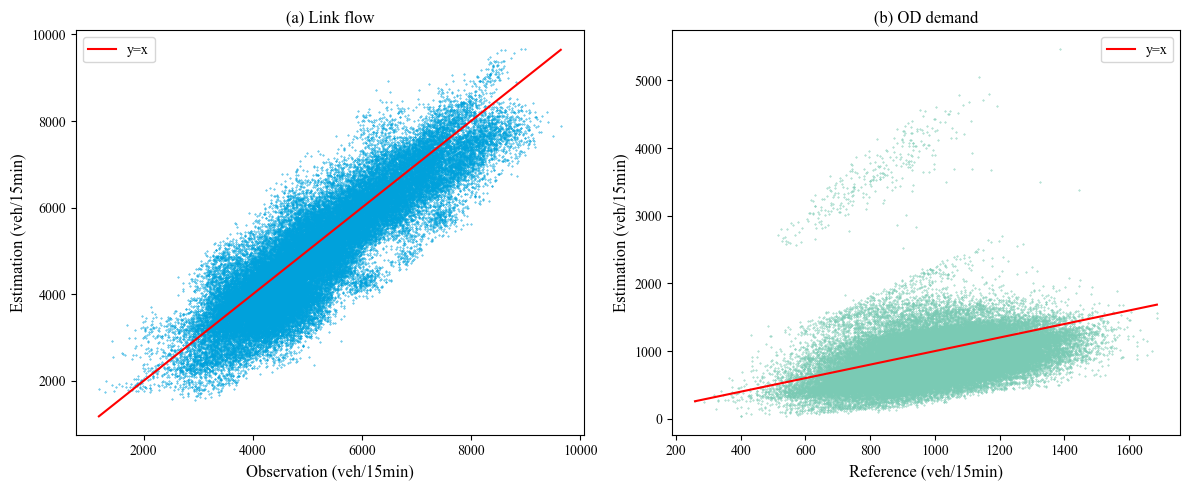

In [648]:
fig = plt.figure()
fig.set_size_inches(12,5)

plt.rc('font',family='Times New Roman')

# Link flow scatter
ax1 = fig.add_subplot(1,2,1)
ax1.scatter(x, y, marker='.', s=0.5, c='#00A1DB')
ax1.plot([min(x),max(x)],[min(x),max(x)], c='r', label='y=x')
ax1.legend()
ax1.set_xlabel('Observation (veh/15min)', fontsize=12)
ax1.set_ylabel('Estimation (veh/15min)', fontsize=12)
ax1.set_title('(a) Link flow', fontsize=12)

# OD demand scatter
ax2 = fig.add_subplot(1,2,2)
ax2.scatter(x2, y2, marker='.', s=0.5, c='#7ACAB4')
ax2.plot([min(x2),max(x2)],[min(x2),max(x2)], c='r', label='y=x')
ax2.legend()
ax2.set_xlabel('Reference (veh/15min)', fontsize=12)
ax2.set_ylabel('Estimation (veh/15min)', fontsize=12)
ax2.set_title('(b) OD demand', fontsize=12)

plt.tight_layout()
plt.savefig(f'{figure_dir}/demand_flow_pred.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Performance Metrics

In [649]:
# --- Constants ---
T = 8
num_link = 76
num_od = 96
unobserved_link = np.array([47, 41, 67, 21, 25, 7, 61, 13, 37, 4])  # 1-indexed
observed_link = np.setdiff1d(np.arange(1, num_link + 1), unobserved_link)

# --- Reshape flat data back to (T, num_samples, num_features) ---
n_samples = len(link_flow) // (T * num_link)  # 100
est_flow = link_flow['Estimation'].values.reshape(T, n_samples, num_link)
obs_flow = link_flow['Observation'].values.reshape(T, n_samples, num_link)

n_samples_od = len(od_demand) // (T * num_od)  # 100
est_dem = od_demand['Estimation'].values.reshape(T, n_samples_od, num_od)
ref_dem = od_demand['Reference'].values.reshape(T, n_samples_od, num_od)

# --- Helper functions ---
def rmse(est, obs):
    return np.sqrt(np.mean((est - obs) ** 2))

def mae(est, obs):
    return np.mean(np.abs(est - obs))

def mape(est, obs):
    return 100.0 * np.mean(np.abs((est - obs) / obs))

# --- Compute metrics by category ---
obs_idx = observed_link - 1
unobs_idx = unobserved_link - 1

categories = ['Link flow (with sensors)', 'Link flow (without sensors)',
              'Link flow (total)', 'OD demand']
results = []

for cat in categories:
    if cat == 'Link flow (with sensors)':
        e, o = est_flow[:, :, obs_idx], obs_flow[:, :, obs_idx]
    elif cat == 'Link flow (without sensors)':
        e, o = est_flow[:, :, unobs_idx], obs_flow[:, :, unobs_idx]
    elif cat == 'Link flow (total)':
        e, o = est_flow, obs_flow
    else:
        e, o = est_dem, ref_dem
    results.append({
        'Category': cat,
        'RMSE': round(rmse(e, o), 2),
        'MAE': round(mae(e, o), 2),
        'MAPE': f'{mape(e, o):.2f}%'
    })

metrics_df = pd.DataFrame(results).set_index('Category')
metrics_df.to_csv(f'{figure_dir}/metrics.csv')
print(f'{figure_dir}/metrics.csv has been saved.')
metrics_df

Figures (S=4 k=5)/metrics.csv has been saved.


,RMSE,MAE,MAPE
Category,,,
Link flow (with sensors),621.27,489.22,9.87%
Link flow (without sensors),1009.18,871.15,17.78%
Link flow (total),684.98,539.47,10.91%
OD demand,342.53,249.43,25.73%


## 5.1 Multi-Template Comparison (Table 3 from Paper)

In [650]:
# --- Multi-Template Comparison Table (Table 3 from paper) ---
# S=1 metrics computed from data; S=2, S=3 hardcoded from published results.
# To recompute S=2/S=3, re-run MTCG-Sioux Falls.ipynb with S=2 and S=3.

flow_types = ['Link flow (with sensors)', 'Link flow (without sensors)',
              'Link flow (total)', 'OD demand']

# S=1: use computed values from metrics_df
s1_rmse = [rmse(est_flow[:,:,obs_idx], obs_flow[:,:,obs_idx]),
           rmse(est_flow[:,:,unobs_idx], obs_flow[:,:,unobs_idx]),
           rmse(est_flow, obs_flow),
           rmse(est_dem, ref_dem)]

rmse_df = pd.DataFrame({'Category': flow_types, 'RMSE': [round(v, 2) for v in s1_rmse]}).set_index('Category')
rmse_df.to_csv(f'{figure_dir}/rmse.csv')
print(f'{figure_dir}/rmse.csv has been saved.')

print('Table 3 – RMSE values:')
for ft, rv in zip(flow_types, s1_rmse):
    print(f'  {ft}: {rv:.2f}')

Figures (S=4 k=5)/rmse.csv has been saved.
Table 3 – RMSE values:
  Link flow (with sensors): 621.27
  Link flow (without sensors): 1009.18
  Link flow (total): 684.98
  OD demand: 342.53


## 5.2 R-squared Score

In [651]:
# --- R-squared Scores ---
r2_flow = r2_score(obs_flow.flatten(), est_flow.flatten())
r2_demand = r2_score(ref_dem.flatten(), est_dem.flatten())

r2_obs = r2_score(obs_flow[:, :, obs_idx].flatten(), est_flow[:, :, obs_idx].flatten())
r2_unobs = r2_score(obs_flow[:, :, unobs_idx].flatten(), est_flow[:, :, unobs_idx].flatten())

r2_df = pd.DataFrame({
    'Category': ['Link flow (with sensors)', 'Link flow (without sensors)',
                 'Link flow (total)', 'OD demand'],
    'R-squared': [round(r2_obs, 4), round(r2_unobs, 4), round(r2_flow, 4), round(r2_demand, 4)]
}).set_index('Category')
r2_df.to_csv(f'{figure_dir}/r_squared.csv')
print(f'{figure_dir}/r_squared.csv has been saved.')
r2_df

Figures (S=4 k=5)/r_squared.csv has been saved.


,R-squared
Category,
Link flow (with sensors),0.7737
Link flow (without sensors),0.3180
Link flow (total),0.7204
OD demand,-2.6862


## 6. Per-Timestep RMSE

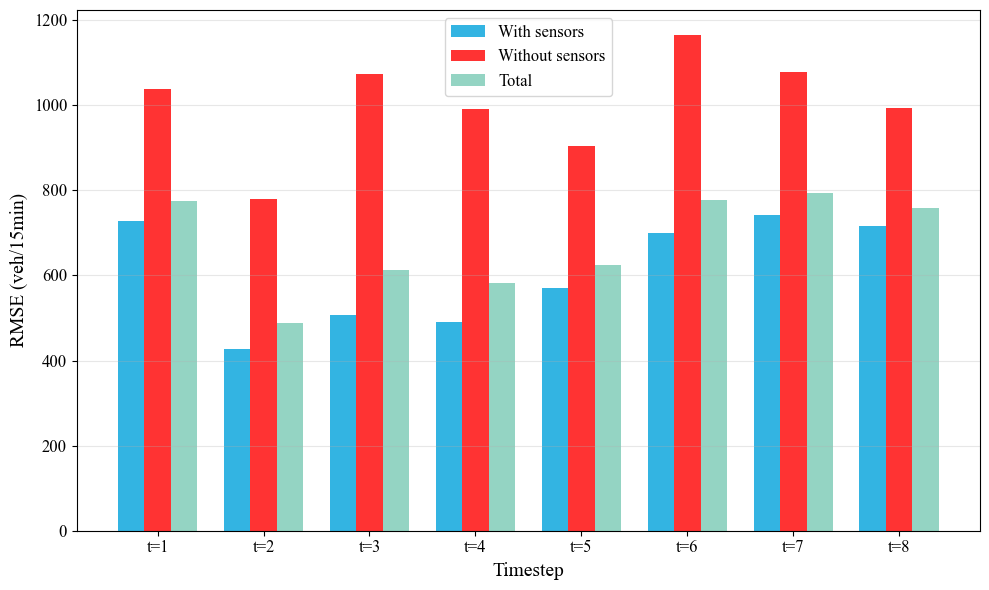

Figures (S=4 k=5)/rmse_per_timestep.csv has been saved.


In [652]:
# --- Per-timestep RMSE bar chart ---
rmse_per_t = np.array([np.sqrt(np.mean((est_flow[t] - obs_flow[t])**2)) for t in range(T)])
rmse_per_t_obs = np.array([np.sqrt(np.mean((est_flow[t, :, obs_idx] - obs_flow[t, :, obs_idx])**2)) for t in range(T)])
rmse_per_t_unobs = np.array([np.sqrt(np.mean((est_flow[t, :, unobs_idx] - obs_flow[t, :, unobs_idx])**2)) for t in range(T)])

plt.rc('font', family='Times New Roman')
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(T)
width = 0.25

ax.bar(x_pos - width, rmse_per_t_obs, width, label='With sensors', color='#00A1DB', alpha=0.8)
ax.bar(x_pos, rmse_per_t_unobs, width, label='Without sensors', color='red', alpha=0.8)
ax.bar(x_pos + width, rmse_per_t, width, label='Total', color='#7ACAB4', alpha=0.8)

ax.set_xlabel('Timestep', fontsize=14)
ax.set_ylabel('RMSE (veh/15min)', fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels([f't={t+1}' for t in range(T)])
ax.tick_params(labelsize=12)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{figure_dir}/rmse_per_timestep.png', dpi=300, bbox_inches='tight')
plt.show()

# Save per-timestep RMSE as CSV
rmse_per_t_df = pd.DataFrame({
    'Timestep': [f't={t+1}' for t in range(T)],
    'With sensors': rmse_per_t_obs,
    'Without sensors': rmse_per_t_unobs,
    'Total': rmse_per_t
})
rmse_per_t_df.to_csv(f'{figure_dir}/rmse_per_timestep.csv', index=False)
print(f'{figure_dir}/rmse_per_timestep.csv has been saved.')

## 7. Observed vs. Unobserved Link Error Comparison

C:\Users\xwu03\AppData\Local\Temp\ipykernel_26212\94218795.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([abs_err_obs, abs_err_unobs],


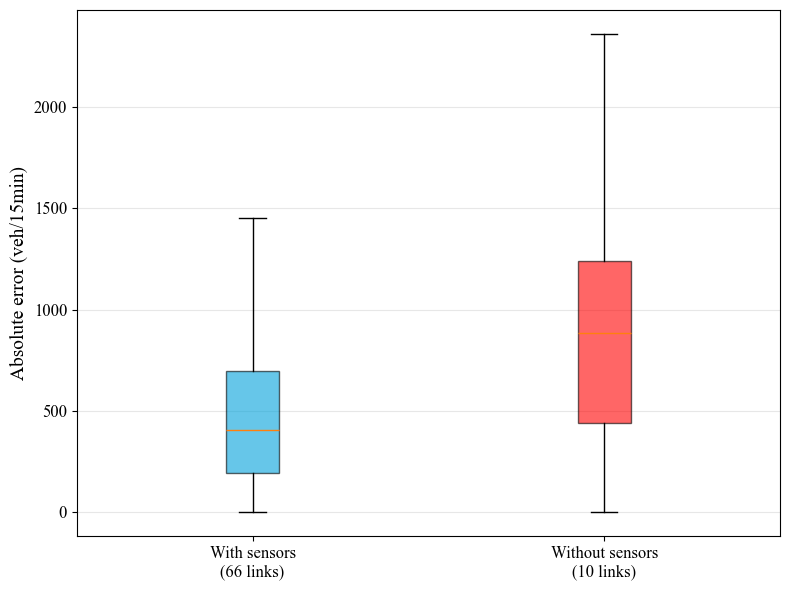

In [653]:
# --- Observed vs. Unobserved box plot ---
abs_err_obs = np.abs(est_flow[:, :, obs_idx] - obs_flow[:, :, obs_idx]).flatten()
abs_err_unobs = np.abs(est_flow[:, :, unobs_idx] - obs_flow[:, :, unobs_idx]).flatten()

plt.rc('font', family='Times New Roman')
fig, ax = plt.subplots(figsize=(8, 6))

bp = ax.boxplot([abs_err_obs, abs_err_unobs],
                labels=['With sensors\n(66 links)', 'Without sensors\n(10 links)'],
                patch_artist=True, showfliers=False)

bp['boxes'][0].set_facecolor('#00A1DB')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('red')
bp['boxes'][1].set_alpha(0.6)

ax.set_ylabel('Absolute error (veh/15min)', fontsize=14)
ax.tick_params(labelsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{figure_dir}/obs_vs_unobs_error.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Loss Component Decomposition

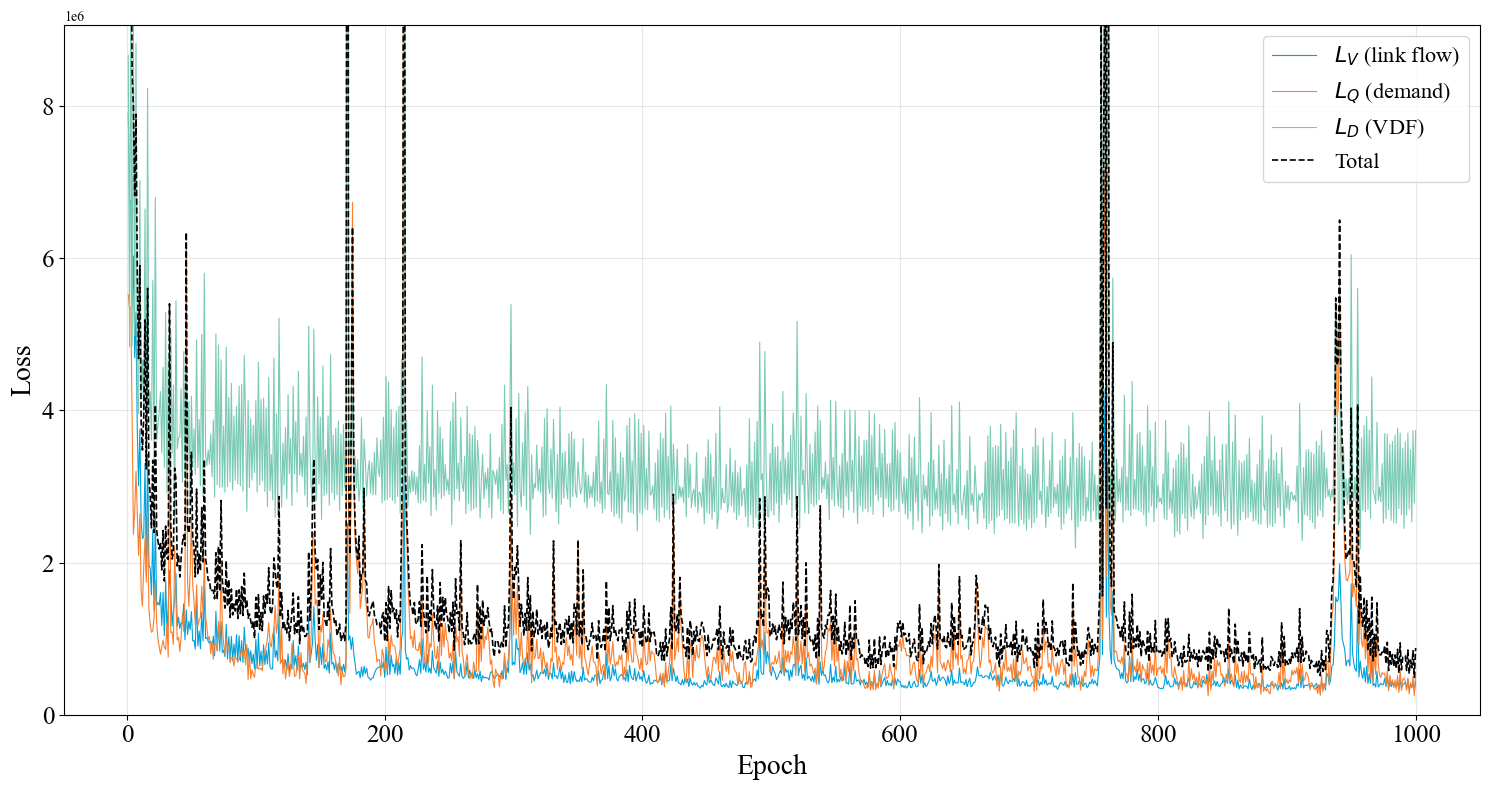

In [654]:
# --- Loss component decomposition (test set) ---
if 'loss_test' not in dir():
    loss_train = pd.read_excel(f'{estimation_dir}/loss_train.xlsx')
    loss_test = pd.read_excel(f'{estimation_dir}/loss_test.xlsx')

plt.rc('font', family='Times New Roman')
fig, ax = plt.subplots(figsize=(15, 8))

epochs = np.arange(1, len(loss_test) + 1)

ax.plot(epochs, loss_test['link_flow'].values, linewidth=0.8, label=r'$L_V$ (link flow)', color='#00A1DB')
ax.plot(epochs, loss_test['demand'].values, linewidth=0.8, label=r'$L_Q$ (demand)', color='#FA7F2C')
ax.plot(epochs, loss_test['vdf'].values, linewidth=0.8, label=r'$L_D$ (VDF)', color='#7ACAB4')
ax.plot(epochs, loss_test['total'].values, linewidth=1.2, label='Total', color='black', linestyle='--')

# Clip y-axis to 99th percentile of the largest component to prevent spikes from crushing the plot
y_cap = np.percentile(loss_test['vdf'].values, 99)
ax.set_ylim(0, y_cap * 1.1)

ax.set_xlabel('Epoch', fontsize=20)
ax.set_ylabel('Loss', fontsize=20)
ax.tick_params(axis='both', labelsize=18)
ax.legend(fontsize=16)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{figure_dir}/loss_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Error Distribution Histogram

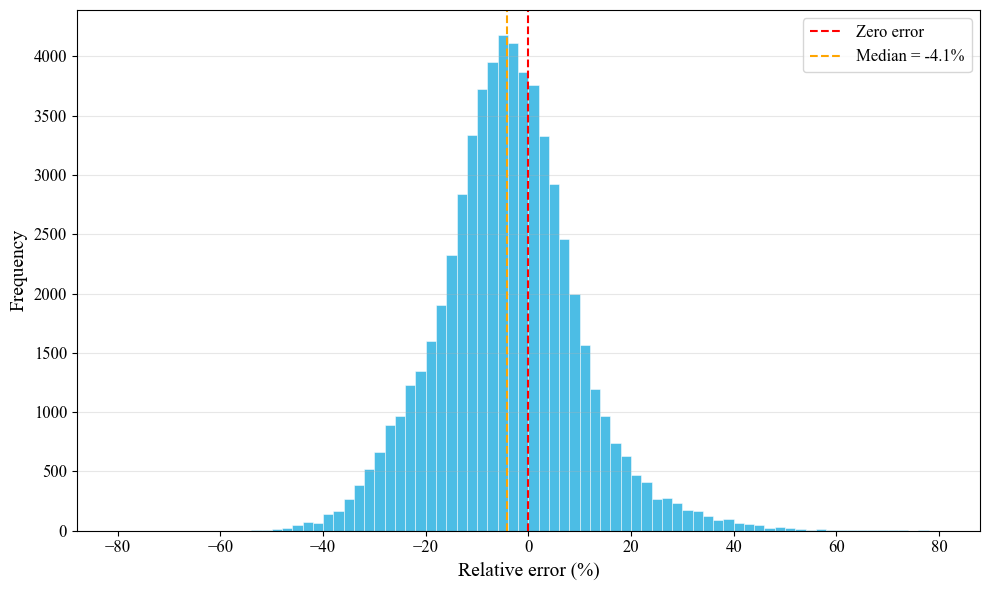

In [655]:
# --- Error distribution histogram ---
relative_errors = ((est_flow - obs_flow) / obs_flow * 100).flatten()

plt.rc('font', family='Times New Roman')
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(relative_errors, bins=80, range=(-80, 80), color='#00A1DB', alpha=0.7, edgecolor='white', linewidth=0.5)
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
ax.axvline(x=np.median(relative_errors), color='orange', linestyle='--', linewidth=1.5,
           label=f'Median = {np.median(relative_errors):.1f}%')

ax.set_xlabel('Relative error (%)', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
ax.tick_params(labelsize=12)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{figure_dir}/error_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Sioux Falls Network Visualisation

Four groups of figures:
1. **Link flow on network** (4 panels): topology, estimated flow, observed flow, estimation error
2. **Template path sets**: visualise the k-shortest-path route sets used by each template
3. **OD demand on network** (3 panels): estimated demand, reference demand, estimation error
4. **Time-dynamic curves**: observed vs estimated flow/demand across timesteps

In [656]:
import networkx as nx
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection
import matplotlib.colors as mcolors

# --- Node coordinates matching fig7.png ---
node_coords = {
    1:  (1, 10),   2:  (5, 10),
    3:  (1, 8),    4:  (2.5, 8),   5:  (3.5, 8),   6:  (5, 8),
    7:  (6.5, 7),  8:  (5, 7),     9:  (3.5, 7),
    10: (3.5, 6),  11: (2.5, 6),   12: (1, 6),
    13: (1, 2),    14: (2.5, 4),   15: (3.5, 4),
    16: (5, 6),    17: (5, 5),
    18: (6.5, 6),  19: (5, 4),
    20: (5, 2),    21: (3.5, 2),   22: (3.5, 3),
    23: (2.5, 3),  24: (2.5, 2),
}

# Load link attributes and OD pairs
link_attr = pd.read_csv('data/link_attributes.csv')
od_pairs_df = pd.read_csv('data/od_pair.csv')

# Build directed graph with link numbers
G = nx.DiGraph()
edge_list = []
link_to_edge = {}
for _, row in link_attr.iterrows():
    s, e = int(row['start']), int(row['end'])
    G.add_edge(s, e, link_num=int(row['link number']))
    edge_list.append((s, e))
    link_to_edge[int(row['link number'])] = (s, e)

# OD pair list
od_list = [(int(row['origin']), int(row['destination'])) for _, row in od_pairs_df.iterrows()]

# Compute mean values per link
mean_est_flow = est_flow.mean(axis=(0, 1))
mean_obs_flow = obs_flow.mean(axis=(0, 1))
mape_per_link = 100.0 * np.abs((est_flow - obs_flow) / obs_flow).mean(axis=(0, 1))

# Compute mean values per OD pair
mean_est_dem = est_dem.mean(axis=(0, 1))
mean_ref_dem = ref_dem.mean(axis=(0, 1))
mape_per_od = 100.0 * np.abs((est_dem - ref_dem) / ref_dem).mean(axis=(0, 1))

obs_set = set(observed_link.tolist())
unobs_set = set(unobserved_link.tolist())

# Edge set for bidirectional detection
edge_set_all = set()
for _, row in link_attr.iterrows():
    edge_set_all.add((int(row['start']), int(row['end'])))

NODE_R = 0.22
SEP = 0.12

def draw_nodes_custom(ax, node_r=0.22):
    """Draw nodes matching fig7.png style."""
    for node, (x, y) in node_coords.items():
        circle = plt.Circle((x, y), node_r, facecolor='white',
                             edgecolor='black', linewidth=1.5, zorder=6)
        ax.add_patch(circle)
        ax.text(x, y, str(node), ha='center', va='center',
                fontsize=11, fontweight='bold', zorder=7,
                fontfamily='Times New Roman')

def draw_topology_arrows(ax):
    """Draw straight parallel arrows matching fig7.png style (no labels)."""
    all_links = [(int(row['link number']), int(row['start']), int(row['end']))
                 for _, row in link_attr.iterrows()]
    for ln, s, e in all_links:
        x0, y0 = node_coords[s]
        x1, y1 = node_coords[e]
        is_unobs = ln in unobs_set
        has_reverse = (e, s) in edge_set_all

        dx, dy = x1 - x0, y1 - y0
        length = np.sqrt(dx**2 + dy**2)
        ux, uy = dx / length, dy / length

        if has_reverse:
            lo, hi = min(s, e), max(s, e)
            cx0, cy0 = node_coords[lo]
            cx1, cy1 = node_coords[hi]
            cdx, cdy = cx1 - cx0, cy1 - cy0
            clen = np.sqrt(cdx**2 + cdy**2)
            cpx, cpy = -cdy / clen, cdx / clen
            side = 1 if s < e else -1
            ox, oy = cpx * SEP * side, cpy * SEP * side
        else:
            ox, oy = 0, 0

        start_x = x0 + ox + ux * NODE_R
        start_y = y0 + oy + uy * NODE_R
        end_x = x1 + ox - ux * NODE_R
        end_y = y1 + oy - uy * NODE_R

        color = '#CC0000' if is_unobs else 'black'
        lw = 1.6 if is_unobs else 0.8
        alpha = 1.0 if is_unobs else 0.75

        arrow = mpatches.FancyArrowPatch(
            (start_x, start_y), (end_x, end_y),
            arrowstyle='->,head_length=5,head_width=3',
            color=color, linewidth=lw, alpha=alpha,
            zorder=2 if is_unobs else 1)
        ax.add_patch(arrow)

# --- Heatmap helpers using networkx (for panels b,c,d) ---
def draw_nodes_nx(ax):
    nx.draw_networkx_nodes(G, node_coords, ax=ax, node_size=280,
                           node_color='white', edgecolors='black', linewidths=1.0)
    nx.draw_networkx_labels(G, node_coords, ax=ax, font_size=7,
                            font_family='Times New Roman', font_weight='bold')

def draw_link_heatmap(ax, values, cmap, clabel, title, vmin=None, vmax=None):
    draw_nodes_nx(ax)
    vmin = vmin if vmin is not None else min(values)
    vmax = vmax if vmax is not None else max(values)
    nx.draw_networkx_edges(
        G, node_coords, edgelist=edge_list, ax=ax,
        edge_color=values, edge_cmap=cmap, edge_vmin=vmin, edge_vmax=vmax,
        width=2.5, arrows=True, arrowsize=10,
        connectionstyle='arc3,rad=0.1', alpha=0.85)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cb = plt.colorbar(sm, ax=ax, shrink=0.7, pad=0.02)
    cb.set_label(clabel, fontsize=10)
    cb.ax.tick_params(labelsize=9)
    ax.set_title(title, fontsize=14, pad=8)
    ax.axis('off')

def draw_od_heatmap(ax, values, cmap, clabel, title, vmin=None, vmax=None):
    draw_nodes_nx(ax)
    vmin = vmin if vmin is not None else min(values)
    vmax = vmax if vmax is not None else max(values)
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    segments, colors = [], []
    for idx, (o, d) in enumerate(od_list):
        x0, y0 = node_coords[o]
        x1, y1 = node_coords[d]
        segments.append([(x0, y0), (x1, y1)])
        colors.append(values[idx])
    lc = LineCollection(segments, cmap=cmap, norm=norm, linewidths=1.8, alpha=0.55)
    lc.set_array(np.array(colors))
    ax.add_collection(lc)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, ax=ax, shrink=0.7, pad=0.02)
    cb.set_label(clabel, fontsize=10)
    cb.ax.tick_params(labelsize=9)
    ax.set_title(title, fontsize=14, pad=8)
    ax.set_xlim(0, 7.5)
    ax.set_ylim(1, 11)
    ax.set_aspect('equal')
    ax.axis('off')

print(f'Setup complete: {len(edge_list)} links, {len(od_list)} OD pairs, {T} timesteps')


Setup complete: 76 links, 96 OD pairs, 8 timesteps


### 10.1 Link Flow on Network
Four panels: (a) network topology with observed/unobserved links, (b) estimated link flow, (c) observed link flow, (d) estimation error.

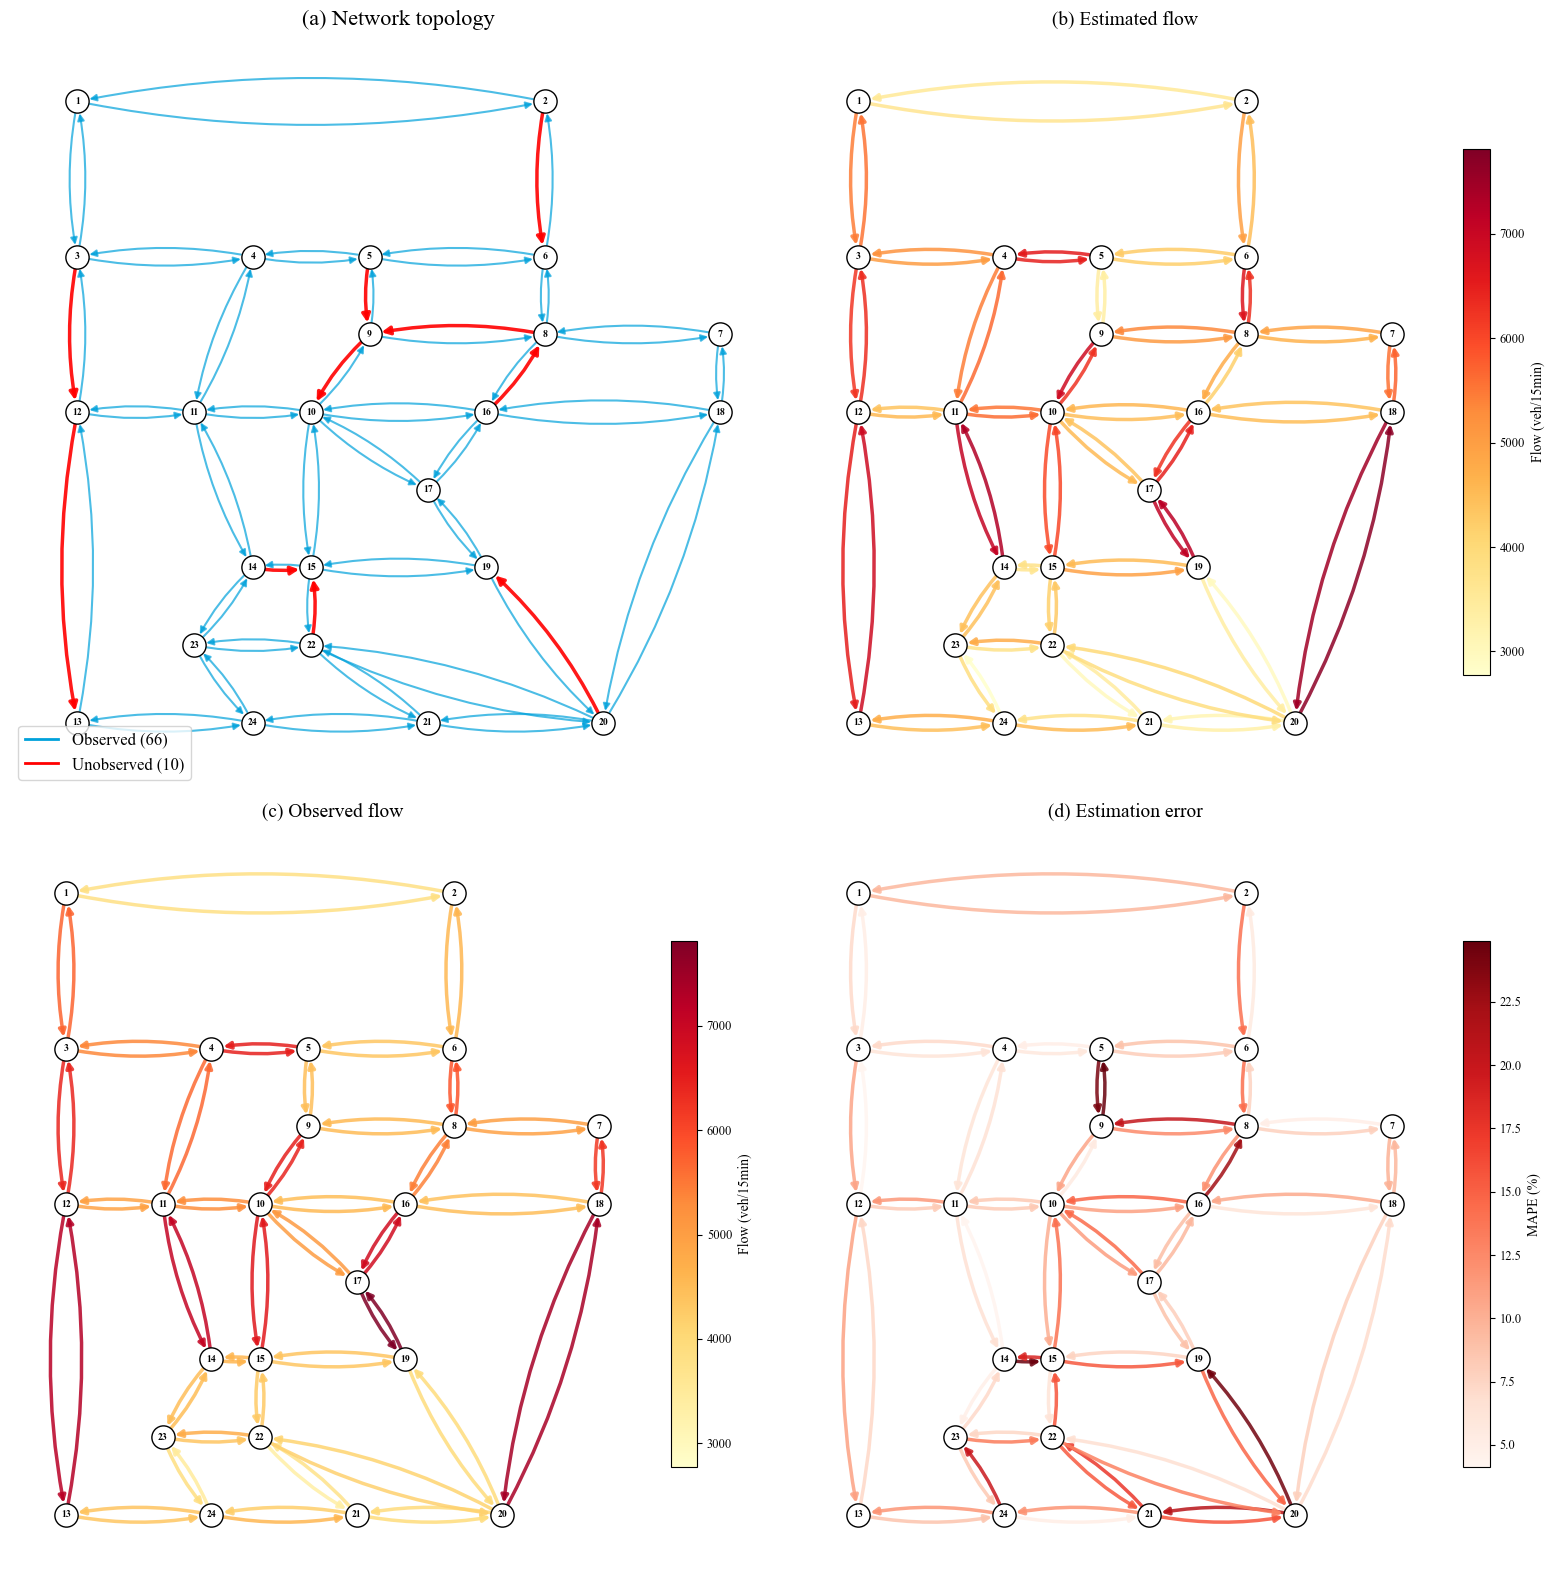

In [657]:
# === 10.1 Link Flow on Network (2x2 layout) ===
plt.rc('font', family='Times New Roman')
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# Use shared colour scale for (b) and (c)
flow_vmin = min(mean_est_flow.min(), mean_obs_flow.min())
flow_vmax = max(mean_est_flow.max(), mean_obs_flow.max())

# (a) Network topology — matching fig7.png style
ax = axes[0, 0]
obs_edges = [e for i, e in enumerate(edge_list) if (i + 1) in obs_set]
unobs_edges = [e for i, e in enumerate(edge_list) if (i + 1) in unobs_set]
draw_topology_arrows(ax)
draw_nodes_custom(ax)
ax.set_xlim(-0.3, 7.5)
ax.set_ylim(1.0, 11.0)
ax.set_aspect('equal')
ax.set_title('(a) Network topology', fontsize=16, pad=8)
legend_elements = [Line2D([0], [0], color='black', lw=1.0, alpha=0.75, label=f'With sensor ({len(obs_edges)})'),
                   Line2D([0], [0], color='#CC0000', lw=2.0, label=f'Without sensor ({len(unobs_edges)})')]
ax.legend(handles=legend_elements, fontsize=12, loc='lower left')
ax.axis('off')

# (b) Flow estimation
draw_link_heatmap(axes[0, 1], mean_est_flow.tolist(), plt.cm.YlOrRd,
                  'Flow (veh/15min)', '(b) Estimated flow', vmin=flow_vmin, vmax=flow_vmax)

# (c) Observed flow
draw_link_heatmap(axes[1, 0], mean_obs_flow.tolist(), plt.cm.YlOrRd,
                  'Flow (veh/15min)', '(c) Observed flow', vmin=flow_vmin, vmax=flow_vmax)

# (d) Estimation error
draw_link_heatmap(axes[1, 1], mape_per_link.tolist(), plt.cm.Reds,
                  'MAPE (%)', '(d) Estimation error')

plt.tight_layout()
plt.savefig(f'{figure_dir}/sioux_falls_link_flow.png', dpi=300, bbox_inches='tight')
plt.show()


### 10.3 OD Demand on Network
Three panels: (a) estimated demand, (b) reference demand, (c) estimation error. OD pairs shown as desire lines between origin and destination nodes.

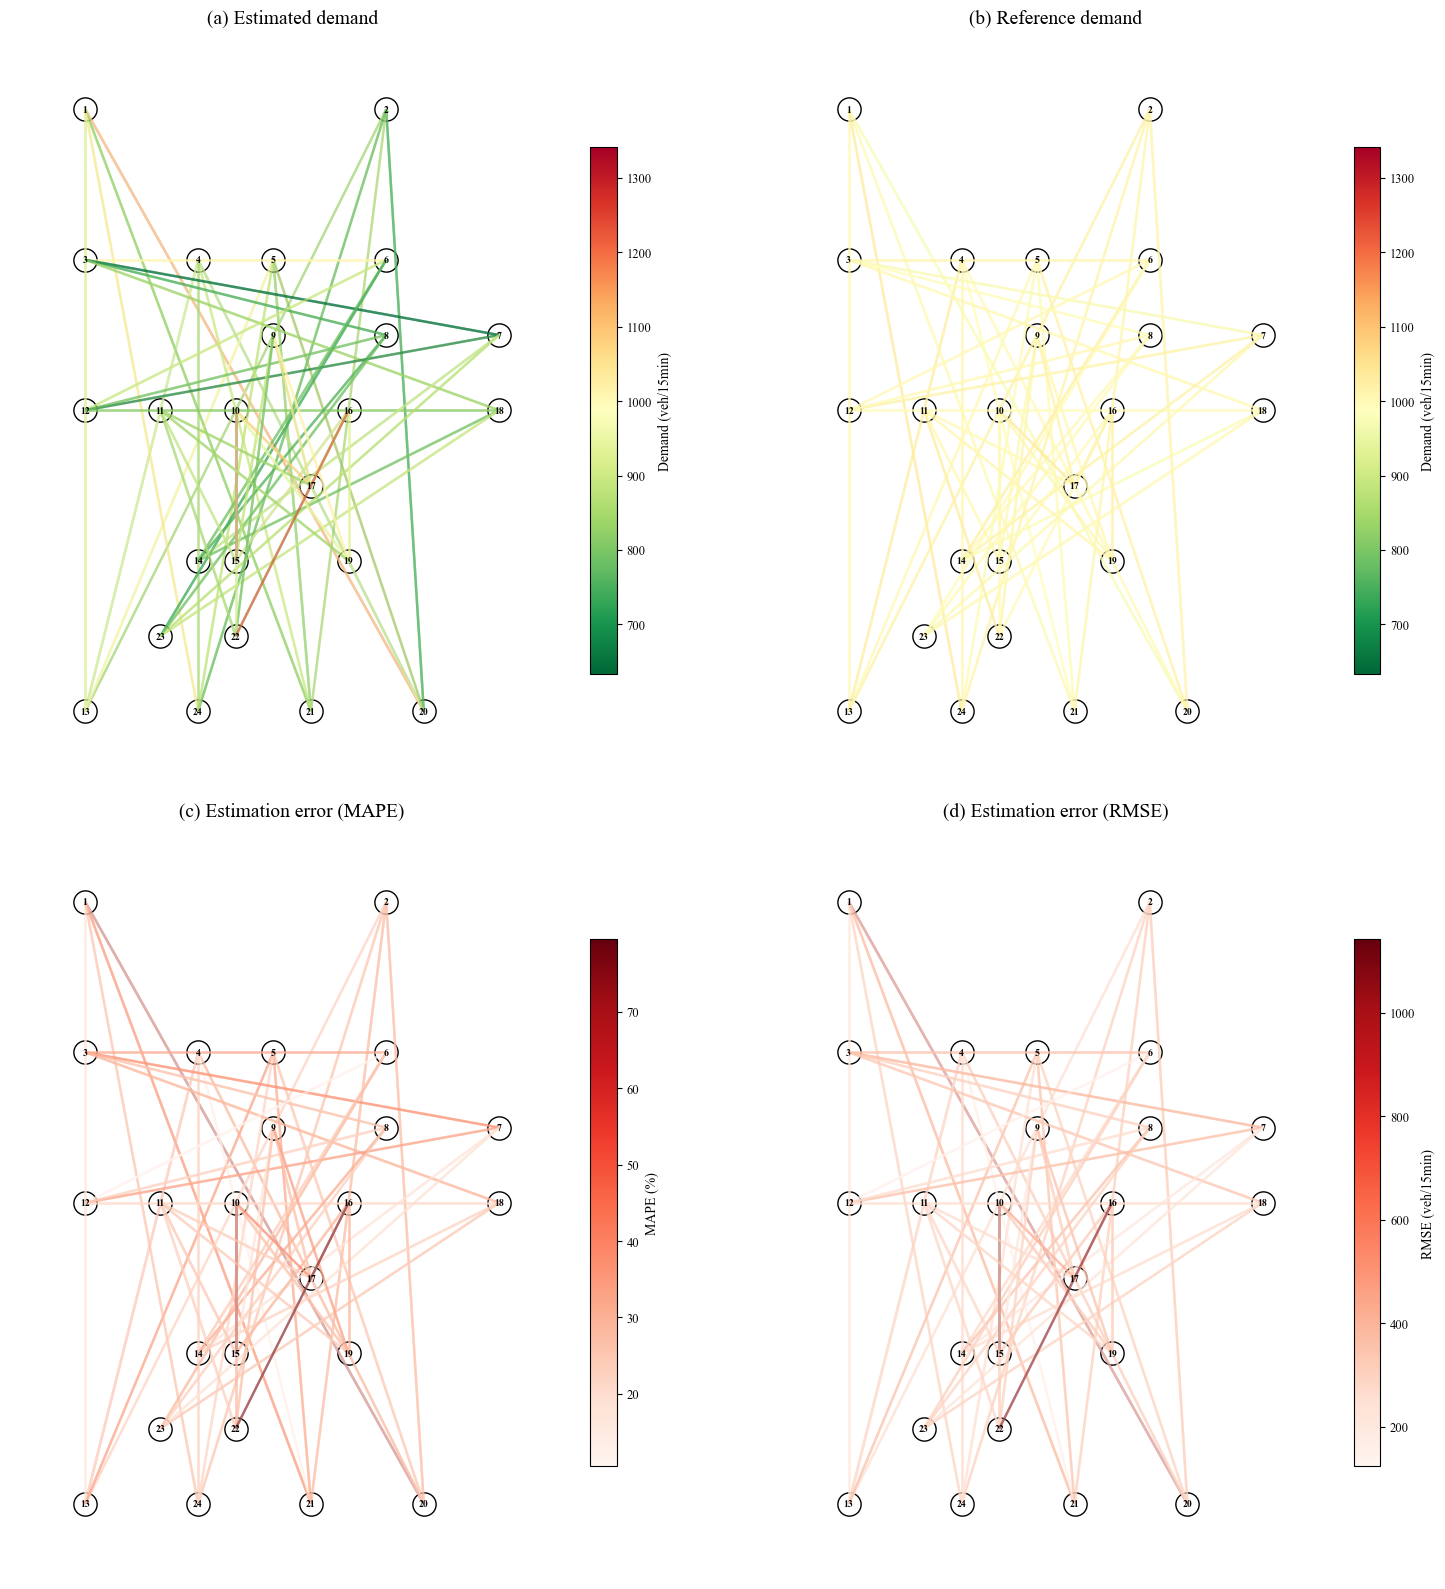

In [658]:
# === 10.3 OD Demand on Network (2x2 layout) ===
plt.rc('font', family='Times New Roman')
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# Shared scale for (a) and (b)
dem_vmin = min(mean_est_dem.min(), mean_ref_dem.min())
dem_vmax = max(mean_est_dem.max(), mean_ref_dem.max())

# RMSE per OD pair
rmse_per_od = np.sqrt(((est_dem - ref_dem) ** 2).mean(axis=(0, 1)))  # (96,)

def draw_od_heatmap_v2(ax, values, cmap, clabel, title, vmin=None, vmax=None):
    """OD heatmap using fig7-style node layout."""
    vmin = vmin if vmin is not None else min(values)
    vmax = vmax if vmax is not None else max(values)
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    segments, colors = [], []
    for idx, (o, d) in enumerate(od_list):
        x0, y0 = node_coords[o]
        x1, y1 = node_coords[d]
        segments.append([(x0, y0), (x1, y1)])
        colors.append(values[idx])
    lc = LineCollection(segments, cmap=cmap, norm=norm, linewidths=1.8, alpha=0.55)
    lc.set_array(np.array(colors))
    ax.add_collection(lc)
    # Draw nodes on top matching fig7 style
    draw_nodes_custom(ax, node_r=0.22)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, ax=ax, shrink=0.7, pad=0.02)
    cb.set_label(clabel, fontsize=10)
    cb.ax.tick_params(labelsize=9)
    ax.set_title(title, fontsize=14, pad=8)
    ax.set_xlim(-0.3, 7.5)
    ax.set_ylim(1.0, 11.0)
    ax.set_aspect('equal')
    ax.axis('off')

# (a) Estimated demand
draw_od_heatmap_v2(axes[0, 0], mean_est_dem.tolist(), plt.cm.RdYlGn_r,
                'Demand (veh/15min)', '(a) Estimated demand', vmin=dem_vmin, vmax=dem_vmax)

# (b) Reference demand
draw_od_heatmap_v2(axes[0, 1], mean_ref_dem.tolist(), plt.cm.RdYlGn_r,
                'Demand (veh/15min)', '(b) Reference demand', vmin=dem_vmin, vmax=dem_vmax)

# (c) MAPE
draw_od_heatmap_v2(axes[1, 0], mape_per_od.tolist(), plt.cm.Reds,
                'MAPE (%)', '(c) Estimation error (MAPE)')

# (d) RMSE
draw_od_heatmap_v2(axes[1, 1], rmse_per_od.tolist(), plt.cm.Reds,
                'RMSE (veh/15min)', '(d) Estimation error (RMSE)')

plt.tight_layout()
plt.savefig(f'{figure_dir}/sioux_falls_od_demand.png', dpi=300, bbox_inches='tight')
plt.show()


### 10.4 Time-Dynamic Curves
Show observed vs estimated link flow and OD demand across the 8 timesteps.
- Left: total link flow per timestep
- Centre: observed vs unobserved link flow per timestep
- Right: OD demand per timestep

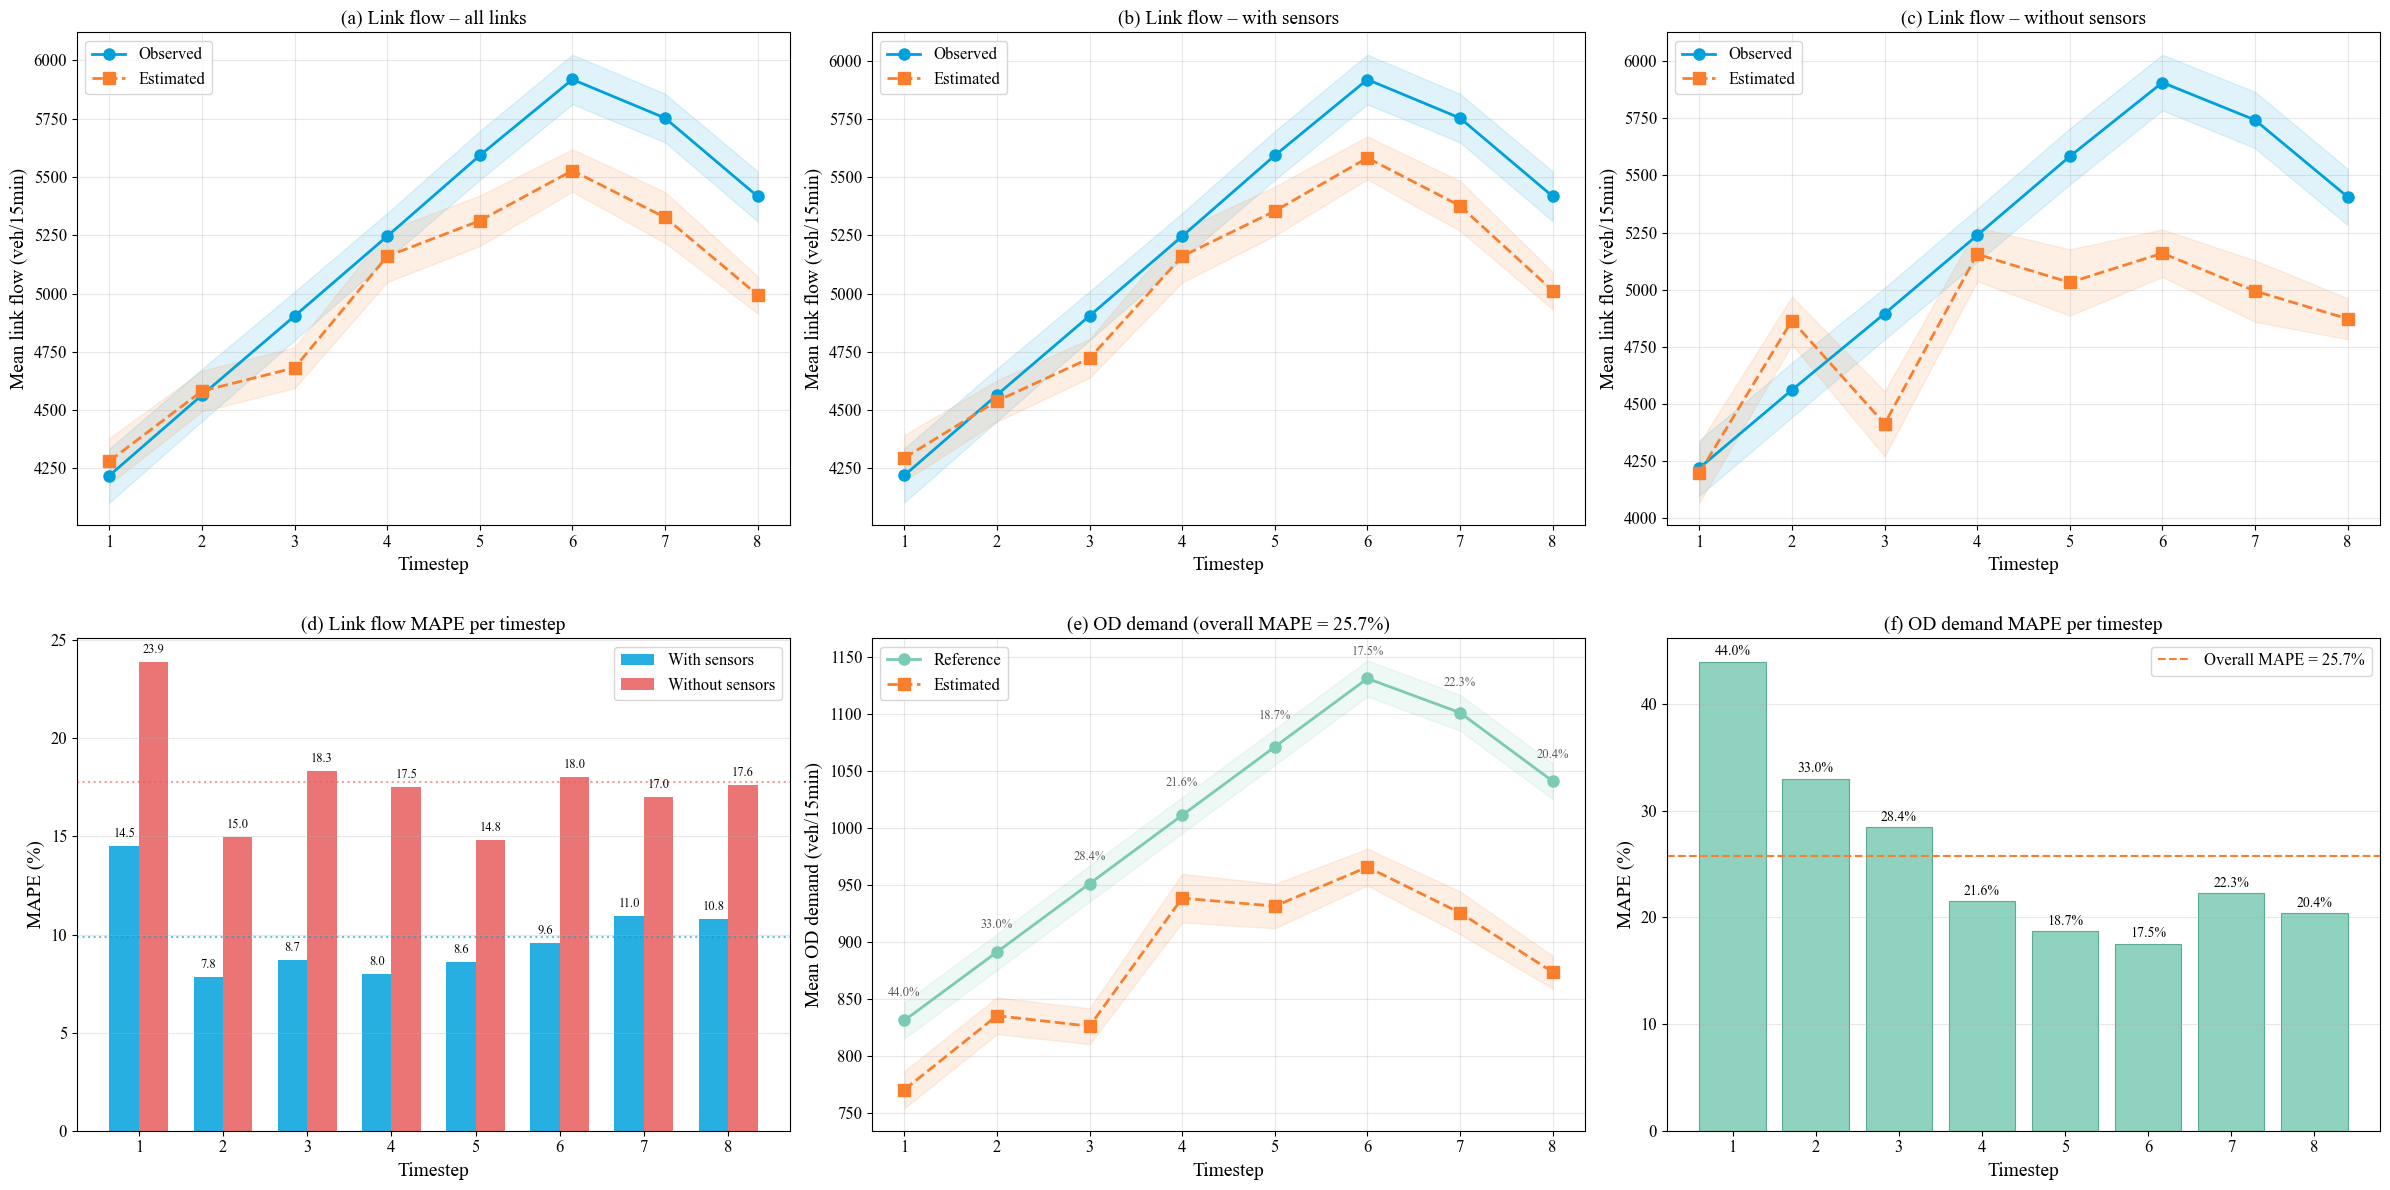

In [659]:
# === 10.4 Time-Dynamic Curves (2×3 layout) ===
plt.rc('font', family='Times New Roman')
fig, axes = plt.subplots(2, 3, figsize=(24, 12))

timesteps = np.arange(1, T + 1)

# ============================================================
# Row 1 – Raw values (observed vs estimated)
# ============================================================

# --- (a) Link flow -- all links ---
ax = axes[0, 0]
mean_est_per_t = est_flow.mean(axis=(1, 2))   # (T,)
mean_obs_per_t = obs_flow.mean(axis=(1, 2))   # (T,)
std_est_per_t = est_flow.mean(axis=2).std(axis=1)   # std across samples
std_obs_per_t = obs_flow.mean(axis=2).std(axis=1)
ax.plot(timesteps, mean_obs_per_t, 'o-', color='#00A1DB', linewidth=2, markersize=8, label='Observed')
ax.plot(timesteps, mean_est_per_t, 's--', color='#FA7F2C', linewidth=2, markersize=8, label='Estimated')
ax.fill_between(timesteps, mean_obs_per_t - std_obs_per_t, mean_obs_per_t + std_obs_per_t,
                alpha=0.12, color='#00A1DB')
ax.fill_between(timesteps, mean_est_per_t - std_est_per_t, mean_est_per_t + std_est_per_t,
                alpha=0.12, color='#FA7F2C')
ax.set_xlabel('Timestep', fontsize=14)
ax.set_ylabel('Mean link flow (veh/15min)', fontsize=14)
ax.set_title('(a) Link flow – all links', fontsize=14)
ax.legend(fontsize=12)
ax.tick_params(labelsize=12)
ax.set_xticks(timesteps)
ax.grid(True, alpha=0.3)

# --- (b) Link flow -- with sensors ---
ax = axes[0, 1]
est_obs_t = est_flow[:, :, obs_idx].mean(axis=2)   # (T, n_samples)
obs_obs_t = obs_flow[:, :, obs_idx].mean(axis=2)
ax.plot(timesteps, obs_obs_t.mean(axis=1), 'o-', color='#00A1DB', linewidth=2, markersize=8, label='Observed')
ax.plot(timesteps, est_obs_t.mean(axis=1), 's--', color='#FA7F2C', linewidth=2, markersize=8, label='Estimated')
ax.fill_between(timesteps,
                obs_obs_t.mean(axis=1) - obs_obs_t.std(axis=1),
                obs_obs_t.mean(axis=1) + obs_obs_t.std(axis=1),
                alpha=0.12, color='#00A1DB')
ax.fill_between(timesteps,
                est_obs_t.mean(axis=1) - est_obs_t.std(axis=1),
                est_obs_t.mean(axis=1) + est_obs_t.std(axis=1),
                alpha=0.12, color='#FA7F2C')
ax.set_xlabel('Timestep', fontsize=14)
ax.set_ylabel('Mean link flow (veh/15min)', fontsize=14)
ax.set_title('(b) Link flow – with sensors', fontsize=14)
ax.legend(fontsize=12)
ax.tick_params(labelsize=12)
ax.set_xticks(timesteps)
ax.grid(True, alpha=0.3)

# --- (c) Link flow -- without sensors ---
ax = axes[0, 2]
est_unobs_t = est_flow[:, :, unobs_idx].mean(axis=2)   # (T, n_samples)
obs_unobs_t = obs_flow[:, :, unobs_idx].mean(axis=2)
ax.plot(timesteps, obs_unobs_t.mean(axis=1), 'o-', color='#00A1DB', linewidth=2, markersize=8, label='Observed')
ax.plot(timesteps, est_unobs_t.mean(axis=1), 's--', color='#FA7F2C', linewidth=2, markersize=8, label='Estimated')
ax.fill_between(timesteps,
                obs_unobs_t.mean(axis=1) - obs_unobs_t.std(axis=1),
                obs_unobs_t.mean(axis=1) + obs_unobs_t.std(axis=1),
                alpha=0.12, color='#00A1DB')
ax.fill_between(timesteps,
                est_unobs_t.mean(axis=1) - est_unobs_t.std(axis=1),
                est_unobs_t.mean(axis=1) + est_unobs_t.std(axis=1),
                alpha=0.12, color='#FA7F2C')
ax.set_xlabel('Timestep', fontsize=14)
ax.set_ylabel('Mean link flow (veh/15min)', fontsize=14)
ax.set_title('(c) Link flow – without sensors', fontsize=14)
ax.legend(fontsize=12)
ax.tick_params(labelsize=12)
ax.set_xticks(timesteps)
ax.grid(True, alpha=0.3)

# ============================================================
# Row 2 – Errors and demand
# ============================================================

# --- (d) Link flow MAPE per timestep: with vs without sensors ---
ax = axes[1, 0]
mape_obs_links = np.abs(est_flow[:, :, obs_idx] - obs_flow[:, :, obs_idx]) / (np.abs(obs_flow[:, :, obs_idx]) + 1e-8)
mape_obs_per_t = mape_obs_links.mean(axis=(1, 2)) * 100   # (T,)
mape_unobs_links = np.abs(est_flow[:, :, unobs_idx] - obs_flow[:, :, unobs_idx]) / (np.abs(obs_flow[:, :, unobs_idx]) + 1e-8)
mape_unobs_per_t = mape_unobs_links.mean(axis=(1, 2)) * 100   # (T,)

bar_w = 0.35
ax.bar(timesteps - bar_w/2, mape_obs_per_t, bar_w, color='#00A1DB', alpha=0.85, label='With sensors')
ax.bar(timesteps + bar_w/2, mape_unobs_per_t, bar_w, color='#E85D5D', alpha=0.85, label='Without sensors')
for i, (v1, v2) in enumerate(zip(mape_obs_per_t, mape_unobs_per_t)):
    ax.text(timesteps[i] - bar_w/2, v1 + 0.3, f'{v1:.1f}', ha='center', va='bottom', fontsize=9)
    ax.text(timesteps[i] + bar_w/2, v2 + 0.3, f'{v2:.1f}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Timestep', fontsize=14)
ax.set_ylabel('MAPE (%)', fontsize=14)
ax.set_title('(d) Link flow MAPE per timestep', fontsize=14)
ax.legend(fontsize=12)
ax.tick_params(labelsize=12)
ax.set_xticks(timesteps)
ax.grid(True, alpha=0.3, axis='y')
overall_mape_obs = mape_obs_links.mean() * 100
overall_mape_unobs = mape_unobs_links.mean() * 100
ax.axhline(overall_mape_obs, color='#00A1DB', linestyle=':', alpha=0.6)
ax.axhline(overall_mape_unobs, color='#E85D5D', linestyle=':', alpha=0.6)

# --- (e) OD demand -- reference vs estimated with std bands ---
ax = axes[1, 1]
mean_est_dem_t = est_dem.mean(axis=(1, 2))   # (T,)
mean_ref_dem_t = ref_dem.mean(axis=(1, 2))   # (T,)
std_est_dem_t = est_dem.mean(axis=2).std(axis=1)
std_ref_dem_t = ref_dem.mean(axis=2).std(axis=1)
ax.plot(timesteps, mean_ref_dem_t, 'o-', color='#7ACAB4', linewidth=2, markersize=8, label='Reference')
ax.plot(timesteps, mean_est_dem_t, 's--', color='#FA7F2C', linewidth=2, markersize=8, label='Estimated')
ax.fill_between(timesteps, mean_ref_dem_t - std_ref_dem_t, mean_ref_dem_t + std_ref_dem_t,
                alpha=0.12, color='#7ACAB4')
ax.fill_between(timesteps, mean_est_dem_t - std_est_dem_t, mean_est_dem_t + std_est_dem_t,
                alpha=0.12, color='#FA7F2C')
od_mape_per_t = (np.abs(est_dem - ref_dem) / (np.abs(ref_dem) + 1e-8)).mean(axis=(1, 2)) * 100
for i, m in enumerate(od_mape_per_t):
    y_pos = max(mean_ref_dem_t[i], mean_est_dem_t[i]) + max(std_est_dem_t[i], std_ref_dem_t[i]) + 2
    ax.text(timesteps[i], y_pos, f'{m:.1f}%', ha='center', va='bottom', fontsize=9, color='#555555')
ax.set_xlabel('Timestep', fontsize=14)
ax.set_ylabel('Mean OD demand (veh/15min)', fontsize=14)
ax.set_title(f'(e) OD demand (overall MAPE = {od_mape_per_t.mean():.1f}%)', fontsize=14)
ax.legend(fontsize=12)
ax.tick_params(labelsize=12)
ax.set_xticks(timesteps)
ax.grid(True, alpha=0.3)

# --- (f) OD demand MAPE per timestep ---
ax = axes[1, 2]
ax.bar(timesteps, od_mape_per_t, color='#7ACAB4', alpha=0.85, edgecolor='#4a9e8a', linewidth=0.8)
for i, m in enumerate(od_mape_per_t):
    ax.text(timesteps[i], m + 0.3, f'{m:.1f}%', ha='center', va='bottom', fontsize=10)
ax.axhline(od_mape_per_t.mean(), color='#FA7F2C', linestyle='--', linewidth=1.5,
           label=f'Overall MAPE = {od_mape_per_t.mean():.1f}%')
ax.set_xlabel('Timestep', fontsize=14)
ax.set_ylabel('MAPE (%)', fontsize=14)
ax.set_title('(f) OD demand MAPE per timestep', fontsize=14)
ax.legend(fontsize=12)
ax.tick_params(labelsize=12)
ax.set_xticks(timesteps)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout(h_pad=3.0)
plt.savefig(f'{figure_dir}/sioux_falls_time_dynamics.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Load Loss Trajectories

Load the training and test loss values recorded at each epoch during training.

In [660]:
loss_train = pd.read_excel(f'{estimation_dir}/loss_train.xlsx')
loss_test = pd.read_excel(f'{estimation_dir}/loss_test.xlsx')
loss_test

,link_flow,demand,vdf,total
0,8.280044e+06,5.367578e+06,8322832.00,1.257564e+07
1,6.391833e+06,5.390159e+06,4988318.00,1.066544e+07
2,5.776363e+06,2.387470e+06,7915315.00,7.731408e+06
3,4.517101e+06,3.415374e+06,4496893.50,7.234850e+06
4,6.615985e+06,3.775030e+06,12659643.00,9.727532e+06
...,...,...,...,...
995,4.022695e+05,1.330255e+06,2607170.00,1.401263e+06
996,4.209781e+05,1.474767e+06,3653167.25,1.544938e+06
997,4.746094e+05,1.228534e+06,2395471.50,1.382642e+06
998,4.862819e+05,1.546527e+06,3806114.25,1.667396e+06


## 11.1 Plot Loss Convergence Curves

Plot the loss function over training epochs for both training and test sets (corresponds to Figure 9 in the paper).

The consistent downward trend on both sets indicates satisfactory convergence and generalisation. Occasional spikes are due to the mini-batch stochastic gradient descent.

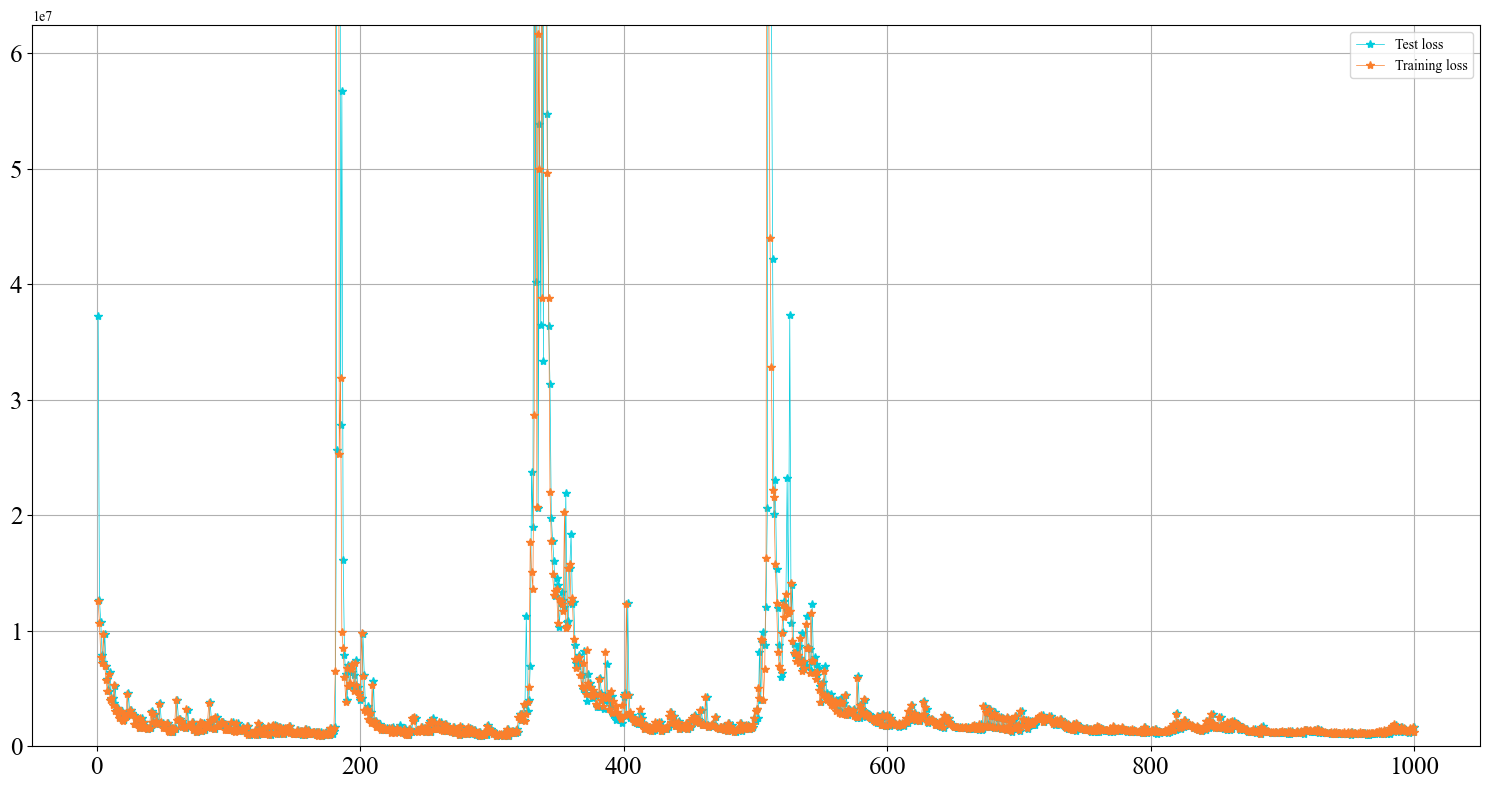

In [661]:
x = np.arange(1, len(loss_test) + 1)  # x-axis data
y1 = loss_test.iloc[:,-1].values
y2 = loss_train.iloc[:,-1].values

plt.rc('font',family='Times New Roman')

plt.figure(figsize=(15, 8))
# Plot line chart
plt.plot(x, y2, color='#00CCDD', linewidth=0.5, label='Test loss', marker='*')
plt.plot(x, y1, color='#FA7F2C', linewidth=0.5, label='Training loss', marker='*')

# Set y-axis bound to 99th percentile to prevent spikes from distorting the view
y_cap = np.percentile(np.concatenate([y1, y2]), 99)
plt.ylim(0, y_cap * 1.1)

# Set legend
plt.legend()

# Adjust parameters
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)

plt.tight_layout()
plt.savefig(f'{figure_dir}/loss.png', dpi=300, bbox_inches='tight')
plt.show()